# Feature Experiments

This notebook evaluates progressively larger feature sets to determine which features improve AQI prediction.

Each feature set is evaluated on a chronological train/validation/test split (not randomized, not walk-forward) using RMSE, MAE, and R², starting from a minimum baseline and progressively adding engineered feature groups. RFECV (Recursive Feature Elimination with Cross-Validation) is used within each experiment to identify candidate feature subsets, with the final feature set for each stage chosen by comparing RFECV's recommendation against actual validation performance and feature-group consistency — not by RFECV's output alone.

## Data Preparation

Run the extraction script below to refresh the local dataset from Hopsworks before running the experiments.

In [ ]:
%run ./scripts/extract_engineered_features.py

### Load and Prepare Data

Load the extracted engineered features, keep rows with complete target values, and sort them chronologically.

In [20]:
import pandas as pd

from src.common.constants import TARGET_COLUMNS, BASELINE_FEATURES
from src.modeling.data_utils import train_and_evaluate_model
from notebooks.eda.utils import select_features_with_rfecv

In [21]:
df = pd.read_parquet("./data/engineered_features.parquet")

# Drop columns which does not have labels
df = (
    df.dropna(subset=TARGET_COLUMNS)
      .sort_values("ts")
      .reset_index(drop=True)
)

In [22]:
print(df.head())

print(df[TARGET_COLUMNS].isna().sum())

    aqi_today   aqi_lag_1   aqi_lag_2   aqi_lag_3  aqi_roll_mean_3  \
0  136.041667  160.208333  159.041667  128.833333       151.763889   
1   82.875000  136.041667  160.208333  159.041667       126.375000   
2  131.625000   82.875000  136.041667  160.208333       116.847222   
3  133.208333  131.625000   82.875000  136.041667       115.902778   
4   96.000000  133.208333  131.625000   82.875000       120.277778   

   aqi_roll_mean_7  aqi_roll_std_3  aqi_roll_std_7  aqi_change_rate  \
0       137.857143       13.628334       20.441267       -24.166667   
1       133.571429       39.562538       28.217694       -53.166667   
2       136.125000       29.503570       26.903172        48.750000   
3       133.119048       28.613848       25.688600         1.583333   
4       128.428571       21.040071       29.339613       -37.208333   

   pm25_today  ...  o3_roll_std_3  o3_roll_std_7  day_of_week  is_weekend  \
0   29.420833  ...      26.853124      17.915527            3       False  

### Chronological Data Split

Split the prepared data chronologically into training, validation, and test sets.

In [23]:
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train:, {len(train_df)}, {train_df["ts"].min()}, →, {train_df["ts"].max()}")
print(f"Validation:, {len(val_df)}, {val_df["ts"].min()}, →, {val_df["ts"].max()}")
print(f"Test:, {len(test_df)}, {test_df["ts"].min()}, →, {test_df["ts"].max()}")

Train:, 1001, 2022-08-11 00:00:00+00:00, →, 2025-05-31 00:00:00+00:00
Validation:, 215, 2025-06-01 00:00:00+00:00, →, 2026-01-05 00:00:00+00:00
Test:, 215, 2026-01-06 00:00:00+00:00, →, 2026-08-12 00:00:00+00:00


## Baseline Experiment

The baseline uses only today's AQI and pollutant features:

- AQI
- PM2.5
- PM10
- O₃
- CO
- NO₂
- SO₂

This establishes the reference performance before testing whether historical, weather, and calendar features improve AQI prediction.

In [24]:
baseline_model, (baseline_rmse, baseline_mae, baseline_r2) = train_and_evaluate_model(train_df, val_df,
                                                                                      toggle_evaluate_print = True, disable_plot=True)


target_aqi_day1
  RMSE: 15.7331
  MAE:  10.0512
  R²:   0.8435

target_aqi_day2
  RMSE: 29.7762
  MAE:  20.8539
  R²:   0.4485

target_aqi_day3
  RMSE: 33.9258
  MAE:  25.1674
  R²:   0.3229

target_aqi_day4
  RMSE: 35.1598
  MAE:  26.9341
  R²:   0.3023


## Experiment 2 — AQI Temporal Features

Add historical AQI features to the baseline feature set:

- AQI lag features
- AQI rolling statistics
- AQI change rate

This tests whether historical AQI behavior improves prediction performance.

In [25]:
AQI_TEMPORAL_FEATURES = [
    "aqi_lag_1",
    "aqi_lag_2",
    "aqi_lag_3",
    "aqi_roll_mean_3",
    "aqi_roll_mean_7",
    "aqi_roll_std_3",
    "aqi_roll_std_7",
    "aqi_change_rate",
]

aqi_temporal_model, (aqi_temporal_rmse, aqi_temporal_mae, aqi_temporal_r2) = train_and_evaluate_model(train_df, val_df,
                         additonal_features=AQI_TEMPORAL_FEATURES,
                         label="AQI Temporal",
                         disable_plot=True,
                         compare_model=("Baseline", (baseline_rmse, baseline_mae, baseline_r2)))

,Target,Baseline RMSE,Baseline MAE,Baseline R²,AQI Temporal RMSE,AQI Temporal MAE,AQI Temporal R²
0,target_aqi_day1,15.733067,10.051240,0.843533,16.185396,10.464076,0.834407
1,target_aqi_day2,29.776182,20.853934,0.448485,29.908333,20.772758,0.443579
2,target_aqi_day3,33.925803,25.167355,0.322946,32.700314,23.881378,0.370977
3,target_aqi_day4,35.159825,26.934099,0.302340,33.562812,25.461045,0.364278
4,Mean,28.648719,20.751657,0.479326,28.089214,20.144814,0.503310


The AQI temporal features slightly reduced performance for the 1-day and 2-day forecasts, but improved performance for the 3-day and 4-day forecasts.

Overall, the mean RMSE and MAE decreased while the mean R² increased. This indicates that the historical AQI features provide useful information for longer forecast horizons and improve the overall four-day prediction performance.

### Experiment 2.1 — Recursive Feature Elimination

Use RFECV to automatically identify the most useful subset of AQI temporal features.

The existing chronological training and validation split is preserved using a `PredefinedSplit`. The selected feature subset will then be compared with the full AQI temporal feature set.

Selected features:
pm25_today
pm10_today
o3_today
co_today
aqi_roll_mean_7

Selected feature count: 5


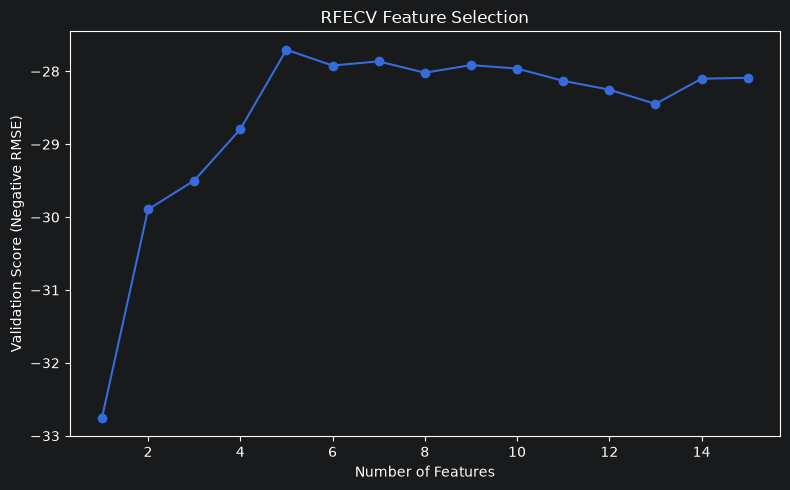

In [27]:
total_features = BASELINE_FEATURES + AQI_TEMPORAL_FEATURES

select_features_with_rfecv(total_features, train_df, val_df)

**Observation:** RFECV identified **5 features** as the optimal feature count, achieving the best validation score with a negative RMSE of approximately **-27.65**. The selected features were `pm25_today`, `pm10_today`, `o3_today`, `co_today`, and `aqi_roll_mean_7`. Performance improved sharply up to 5 features, then generally plateaued or declined as additional features were included. This suggests that a smaller feature set may be sufficient, but the selected set will be tested with the remaining pollutant features restored before making a final pruning decision.

In [26]:
REDUCED_BASELINE_FEATURES = [
    feature
    for feature in BASELINE_FEATURES
    if feature not in {
        "aqi_today",
    }
]

REDUCED_AQI_TEMPORAL_FEATURES = [
    "aqi_roll_mean_7"
]

(rfecv_reduced_aqi_temporal_model,
(rfecv_reduced_aqi_temporal_rmse, rfecv_reduced_aqi_temporal_mae, rfecv_reduced_aqi_temporal_r2)) = train_and_evaluate_model(train_df, val_df,
                         additonal_features=REDUCED_AQI_TEMPORAL_FEATURES,
                         label="RFECV Reduced AQI Temporal",
                         compare_model=("AQI Temporal", (aqi_temporal_rmse, aqi_temporal_mae, aqi_temporal_r2)),
                         disable_plot=True,
                         baseline=REDUCED_BASELINE_FEATURES
                         )

,Target,AQI Temporal RMSE,AQI Temporal MAE,AQI Temporal R²,RFECV Reduced AQI Temporal RMSE,RFECV Reduced AQI Temporal MAE,RFECV Reduced AQI Temporal R²
0,target_aqi_day1,16.185396,10.464076,0.834407,16.130965,10.412754,0.835519
1,target_aqi_day2,29.908333,20.772758,0.443579,29.758598,20.948609,0.449136
2,target_aqi_day3,32.700314,23.881378,0.370977,32.821874,24.115787,0.366292
3,target_aqi_day4,33.562812,25.461045,0.364278,33.195881,25.237203,0.378102
4,Mean,28.089214,20.144814,0.503310,27.976830,20.178588,0.507262


**Observation:** The RFECV-inspired reduced feature set achieved slightly better overall RMSE and R² than the full AQI temporal feature set, while MAE remained nearly unchanged. Since the reduced set uses fewer features without a meaningful loss in performance, it is preferred for its simpler feature space and will be used to define the new baseline for the next experiments.

In [28]:
IMPROVED_BASELINE = [
    feature
    for feature in BASELINE_FEATURES
    if feature not in {
        "aqi_today",
    }
] + ["aqi_roll_mean_7"]

## Experiment 3 — Primary Pollutant Temporal Features

Add historical temporal features for the primary pollutants:

- PM2.5 lag and rolling features
- PM10 lag and rolling features
- O₃ lag and rolling features

This tests whether historical pollutant behavior provides additional predictive information beyond the current pollutant and AQI features.

In [29]:
PRIMARY_POLLUTANT_TEMPORAL_FEATURES = [
    "pm25_lag_1",
    "pm25_lag_2",
    "pm25_lag_3",
    "pm25_roll_mean_3",
    "pm25_roll_mean_7",
    "pm25_roll_std_3",
    "pm25_roll_std_7",

    "pm10_lag_1",
    "pm10_lag_2",
    "pm10_lag_3",
    "pm10_roll_mean_3",
    "pm10_roll_mean_7",
    "pm10_roll_std_3",
    "pm10_roll_std_7",

    "o3_lag_1",
    "o3_lag_2",
    "o3_lag_3",
    "o3_roll_mean_3",
    "o3_roll_mean_7",
    "o3_roll_std_3",
    "o3_roll_std_7",
]

primary_pollutant_temporal_model, (primary_pollutant_temporal_rmse, primary_pollutant_temporal_mae, primary_pollutant_temporal_r2) = train_and_evaluate_model(train_df, val_df,
                         additonal_features=PRIMARY_POLLUTANT_TEMPORAL_FEATURES,
                         label="Primary Pollutant Temporal",
                         compare_model=("RFECV Reduced AQI Temporal",
                                        (rfecv_reduced_aqi_temporal_rmse, rfecv_reduced_aqi_temporal_mae, rfecv_reduced_aqi_temporal_r2)),
                         disable_plot=True,
                         baseline=IMPROVED_BASELINE
                         )

,Target,RFECV Reduced AQI Temporal RMSE,RFECV Reduced AQI Temporal MAE,RFECV Reduced AQI Temporal R²,Primary Pollutant Temporal RMSE,Primary Pollutant Temporal MAE,Primary Pollutant Temporal R²
0,target_aqi_day1,16.130965,10.412754,0.835519,16.004920,10.653828,0.838079
1,target_aqi_day2,29.758598,20.948609,0.449136,28.707930,20.540614,0.487348
2,target_aqi_day3,32.821874,24.115787,0.366292,32.101100,23.710184,0.393819
3,target_aqi_day4,33.195881,25.237203,0.378102,32.298620,24.126421,0.411267
4,Mean,27.976830,20.178588,0.507262,27.278142,19.757762,0.532628


**Observation:** Adding temporal features for the primary pollutants improved overall model performance across all three metrics. Mean RMSE decreased from **27.9768** to **27.2781**, mean MAE decreased from **20.1786** to **19.7578**, and mean R² increased from **0.5073** to **0.5326**. The improvement was also consistent across all four forecast days, indicating that historical PM2.5, PM10, and O₃ behavior provides useful additional information for AQI prediction.

### Experiment 3.1 — Recursive Feature Elimination

Use RFECV to automatically identify the most useful subset of primary pollutant temporal features.

The existing chronological training and validation split is preserved using a `PredefinedSplit`. The selected feature subset will then be compared with the full AQI temporal feature set.

Selected features:
pm25_today
pm10_today
o3_today
co_today
no2_today
so2_today
aqi_roll_mean_7
pm25_lag_1
pm25_lag_2
pm25_lag_3
pm25_roll_mean_3
pm25_roll_mean_7
pm25_roll_std_3
pm25_roll_std_7
pm10_lag_1
pm10_lag_3
pm10_roll_mean_7
pm10_roll_std_3
pm10_roll_std_7
o3_lag_1
o3_lag_2
o3_lag_3
o3_roll_mean_3
o3_roll_mean_7
o3_roll_std_3
o3_roll_std_7

Selected feature count: 26


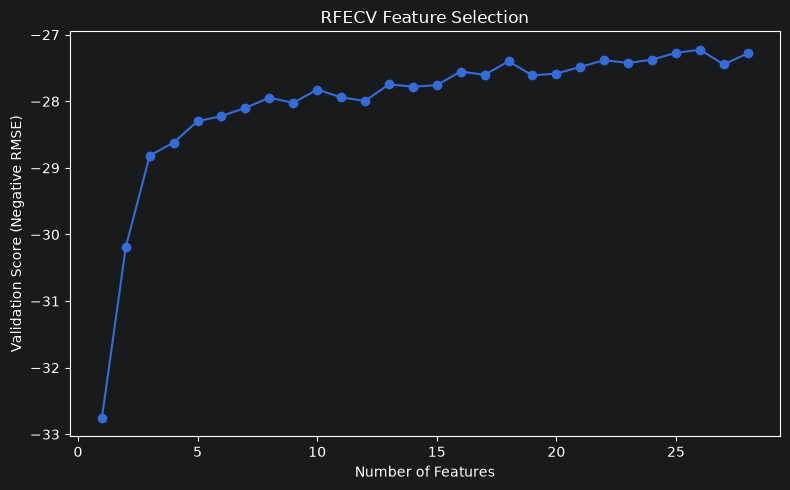

In [30]:
total_features = IMPROVED_BASELINE + PRIMARY_POLLUTANT_TEMPORAL_FEATURES

select_features_with_rfecv(total_features, train_df, val_df)

**Observation:** RFECV selected **26 features** as the optimal subset, excluding `pm10_lag_2` and `pm10_roll_mean_3` while retaining the other temporal features for PM2.5 and O₃. However, the exact RFECV subset will not be adopted directly. Removing individual temporal features from only PM10 would create an inconsistent feature structure, since PM2.5, PM10, and O₃ are all distinct AQI-related pollutants and may contribute differently to future AQI values. The complete temporal structure for each primary pollutant will therefore be retained and evaluated as a structured feature set.

In [31]:
IMPROVED_BASELINE_2 = IMPROVED_BASELINE + PRIMARY_POLLUTANT_TEMPORAL_FEATURES

## Experiment 4 — Weather Features

Add current and recent weather features to the current feature set:

- Temperature: current and 1-day lag
- Humidity: current and 1-day lag
- Wind speed: current and 1-day lag
- Pressure: current and 1-day lag
- Dew point: current and 1-day lag

This tests whether current and recent weather conditions provide additional predictive information for AQI forecasting.

In [32]:
WEATHER_FEATURES = [
    "temp_today",
    "temp_lag_1",

    "humidity_today",
    "humidity_lag_1",

    "wind_spd_today",
    "wind_spd_lag_1",

    "pressure_today",
    "pressure_lag_1",

    "dew_pt_today",
    "dew_pt_lag_1",
]

weather_model, (weather_rmse, weather_mae, weather_r2) = train_and_evaluate_model(train_df, val_df,
                         additonal_features=WEATHER_FEATURES,
                         label="Weather Temporal",
                         compare_model=("Primary Pollutant Temporal",
                                        (primary_pollutant_temporal_rmse, primary_pollutant_temporal_mae, primary_pollutant_temporal_r2)),
                         disable_plot=True,
                         baseline=IMPROVED_BASELINE_2
                         )

,Target,Primary Pollutant Temporal RMSE,Primary Pollutant Temporal MAE,Primary Pollutant Temporal R²,Weather Temporal RMSE,Weather Temporal MAE,Weather Temporal R²
0,target_aqi_day1,16.004920,10.653828,0.838079,16.388169,10.385955,0.830232
1,target_aqi_day2,28.707930,20.540614,0.487348,27.395191,19.499921,0.533160
2,target_aqi_day3,32.101100,23.710184,0.393819,31.960562,23.668744,0.399115
3,target_aqi_day4,32.298620,24.126421,0.411267,35.842248,25.827946,0.274995
4,Mean,27.278142,19.757762,0.532628,27.896543,19.845641,0.509375


**Observation:** Adding the weather features did not improve overall performance compared with the current primary pollutant temporal feature set. Mean RMSE increased from **27.2781** to **27.8965**, mean MAE increased from **19.7578** to **19.8456**, and mean R² decreased from **0.5326** to **0.5094**. Although weather features improved the day-2 and slightly improved the day-3 predictions, they substantially degraded day-4 performance and slightly worsened day-1 performance. RFECV will be used to determine whether a reduced weather feature subset can provide useful information without the overall degradation.

### Experiment 4.1 — Recursive Feature Elimination

Use RFECV to automatically identify the most useful subset of weather features.

The existing chronological training and validation split is preserved using a `PredefinedSplit`. The selected feature subset will then be compared with the full weather feature set.

Selected features:
pm25_today
pm10_today
o3_today
co_today
no2_today
so2_today
aqi_roll_mean_7
pm25_lag_1
pm25_lag_2
pm25_lag_3
pm25_roll_mean_3
pm25_roll_mean_7
pm25_roll_std_3
pm25_roll_std_7
pm10_lag_1
pm10_roll_mean_7
pm10_roll_std_7
o3_lag_2
o3_roll_mean_3
o3_roll_mean_7
o3_roll_std_3
o3_roll_std_7
temp_today
temp_lag_1
humidity_today
humidity_lag_1
wind_spd_today
wind_spd_lag_1
pressure_today
pressure_lag_1
dew_pt_today
dew_pt_lag_1

Selected feature count: 32


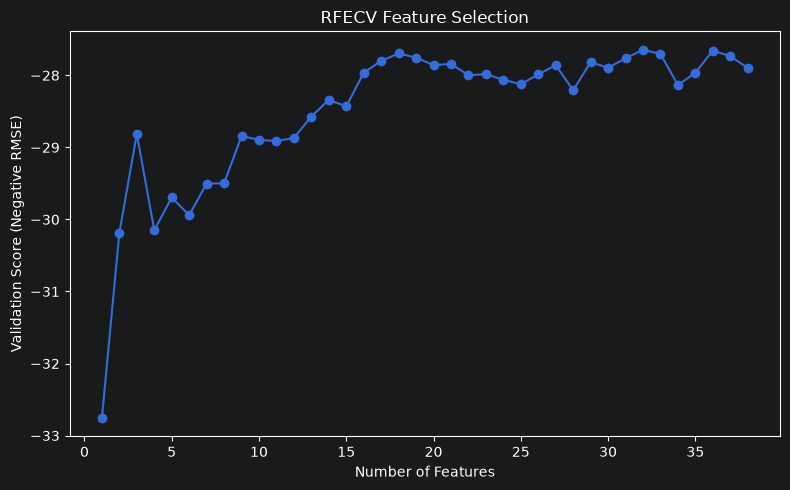

In [33]:
total_features = IMPROVED_BASELINE_2 + WEATHER_FEATURES

select_features_with_rfecv(total_features, train_df, val_df)

**Observation:** RFECV selected **32 features**, with all 10 weather features retained. It also retained all PM2.5 temporal features, while selecting a smaller subset of PM10 and O₃ temporal features. The validation curve showed the best performance at 32 features, with the strongest gains occurring as the feature set increased and diminishing returns appearing near the upper end of the tested range.

This selection is also consistent with the expected relative importance of the primary pollutants: PM2.5 generally contributes the most to AQI, O₃ is also significant, while PM10 typically has a smaller contribution. Therefore, the RFECV result is reasonable, but the exact subset will be adjusted slightly to maintain a more balanced temporal representation across the primary pollutants.

For PM10, the RFECV-selected `pm10_lag_1`, `pm10_roll_mean_7`, and `pm10_roll_std_7` will be retained. For O₃, the RFECV-selected temporal features will be retained and `o3_lag_1` will additionally be included alongside `o3_lag_2` to avoid an unnecessarily asymmetric lag structure. The resulting structured feature set will then be evaluated against the full feature set.

In [34]:
REDUCED_IMRPOVED_BASELINE_2 = [
    feature
    for feature in IMPROVED_BASELINE_2
    if feature not in {
        "pm10_lag_2",
        "pm10_lag_3",
        "pm10_roll_mean_3",
        "pm10_roll_std_3",
        "o3_lag_3",
    }
]

reduced_weather_model, (reduced_weather_rmse, reduced_weather_mae, reduced_weather_r2) = train_and_evaluate_model(train_df, val_df,
                         additonal_features=WEATHER_FEATURES,
                         label="Reduced Weather Temporal",
                         compare_model=("Primary Pollutant Temporal",
                                        (primary_pollutant_temporal_rmse, primary_pollutant_temporal_mae, primary_pollutant_temporal_r2)),
                         disable_plot=True,
                         baseline=REDUCED_IMRPOVED_BASELINE_2
                         )

,Target,Primary Pollutant Temporal RMSE,Primary Pollutant Temporal MAE,Primary Pollutant Temporal R²,Reduced Weather Temporal RMSE,Reduced Weather Temporal MAE,Reduced Weather Temporal R²
0,target_aqi_day1,16.004920,10.653828,0.838079,16.238350,10.349748,0.833322
1,target_aqi_day2,28.707930,20.540614,0.487348,27.495587,19.433610,0.529732
2,target_aqi_day3,32.101100,23.710184,0.393819,32.176016,23.926967,0.390986
3,target_aqi_day4,32.298620,24.126421,0.411267,35.426087,25.730419,0.291733
4,Mean,27.278142,19.757762,0.532628,27.834010,19.860186,0.511443


**Observation:** The reduced weather feature set still failed to improve the current primary pollutant temporal model. Mean RMSE increased from **27.2781** to **27.8340**, mean MAE increased from **19.7578** to **19.8602**, and mean R² decreased from **0.5326** to **0.5114**.

Although the weather features improved the day-2 prediction, the gains were outweighed by degradation on the other prediction horizons, particularly day 4. Therefore, weather features do not provide sufficient additional predictive value to justify their inclusion in the current model and will be excluded from the final feature set.

### Experiment 4.2 — RFECV-Guided Primary Pollutant Feature Reduction

Continue the RFECV analysis from Experiment 3.1 and evaluate a reduced primary pollutant temporal feature set.

The RFECV-selected subset from Experiment 3.1 is used as the starting point. Only `pm10_roll_mean_3`, which was excluded by RFECV, will be removed from the full primary pollutant temporal structure.

The remaining PM2.5, PM10, and O₃ temporal features will be retained to preserve a consistent feature structure across the primary pollutants.

The reduced feature set will be trained and compared with the current primary pollutant temporal model to determine whether this single RFECV-guided reduction improves or maintains performance.

In [35]:
REDUCED_PRIMARY_POLLUTANT_TEMPORAL_FEATURES = [
    feature
    for feature in IMPROVED_BASELINE_2
    if feature not in {
        "pm10_roll_mean_3",
    }
]

reduced_primary_pollutant_temporal_model, (reduced_primary_pollutant_temporal_rmse, reduced_primary_pollutant_temporal_mae, reduced_primary_pollutant_temporal_r2) = train_and_evaluate_model(train_df, val_df,
                         label="Reduced Primary Pollutant Temporal",
                         compare_model=("Primary Pollutant Temporal",
                                        (primary_pollutant_temporal_rmse, primary_pollutant_temporal_mae, primary_pollutant_temporal_r2)),
                         disable_plot=True,
                         baseline=REDUCED_PRIMARY_POLLUTANT_TEMPORAL_FEATURES
                         )

,Target,Primary Pollutant Temporal RMSE,Primary Pollutant Temporal MAE,Primary Pollutant Temporal R²,Reduced Primary Pollutant Temporal RMSE,Reduced Primary Pollutant Temporal MAE,Reduced Primary Pollutant Temporal R²
0,target_aqi_day1,16.004920,10.653828,0.838079,16.172475,10.670411,0.834671
1,target_aqi_day2,28.707930,20.540614,0.487348,28.888427,20.520690,0.480881
2,target_aqi_day3,32.101100,23.710184,0.393819,32.184587,23.847401,0.390661
3,target_aqi_day4,32.298620,24.126421,0.411267,32.414393,24.454700,0.407039
4,Mean,27.278142,19.757762,0.532628,27.414971,19.873300,0.528313


**Observation:** Removing `pm10_roll_mean_3` based on the RFECV result did not improve performance. Mean RMSE increased from **27.2781** to **27.4150**, mean MAE increased from **19.7578** to **19.8733**, and mean R² decreased from **0.5326** to **0.5283**.

The reduction also degraded performance across all four prediction horizons. Therefore, `pm10_roll_mean_3` will be retained despite RFECV excluding it, as removing it does not provide a performance benefit.

## Experiment 5 — Temporal Calendar Features

Add calendar-based temporal features to the current feature set:

- Day of week
- Weekend indicator
- Month

This tests whether weekly and seasonal calendar patterns provide additional predictive information for AQI forecasting.

In [36]:
CALENDAR_FEATURES = [
    "day_of_week",
    "is_weekend",
    "month",
]

calendar_model, (calendar_rmse, calendar_mae, calendar_r2) = train_and_evaluate_model(train_df, val_df,
                         additonal_features=CALENDAR_FEATURES,
                         label="Calendar Temporal",
                         compare_model=("Primary Pollutant Temporal",
                                        (primary_pollutant_temporal_rmse, primary_pollutant_temporal_mae, primary_pollutant_temporal_r2)),
                         disable_plot=True,
                         baseline=IMPROVED_BASELINE_2
                         )

,Target,Primary Pollutant Temporal RMSE,Primary Pollutant Temporal MAE,Primary Pollutant Temporal R²,Calendar Temporal RMSE,Calendar Temporal MAE,Calendar Temporal R²
0,target_aqi_day1,16.004920,10.653828,0.838079,16.151636,10.812690,0.835097
1,target_aqi_day2,28.707930,20.540614,0.487348,28.762298,20.352277,0.485404
2,target_aqi_day3,32.101100,23.710184,0.393819,31.881316,23.287333,0.402091
3,target_aqi_day4,32.298620,24.126421,0.411267,32.129874,24.000124,0.417402
4,Mean,27.278142,19.757762,0.532628,27.231281,19.613106,0.534999


**Observation:** Adding the calendar features produced a small but measurable improvement over the current primary pollutant temporal feature set. Mean RMSE decreased from **27.2781** to **27.2313**, mean MAE decreased from **19.7578** to **19.6131**, and mean R² increased from **0.5326** to **0.5350**.

The improvement was mainly driven by the day-3 and day-4 predictions, while day 1 and day 2 showed slight degradation in some metrics. Despite the relatively small overall gain, the calendar features provide additional predictive information and will therefore be retained for further evaluation.

### Experiment 5.1 — Recursive Feature Elimination

Use RFECV to automatically identify the most useful subset of calendar features.

The existing chronological training and validation split is preserved using a `PredefinedSplit`. The selected feature subset will then be compared with the full calendar feature set.

Selected features:
pm25_today
pm10_today
o3_today
co_today
no2_today
so2_today
aqi_roll_mean_7
pm25_lag_1
pm25_lag_2
pm25_lag_3
pm25_roll_mean_3
pm25_roll_mean_7
pm25_roll_std_3
pm25_roll_std_7
pm10_roll_mean_7
pm10_roll_std_3
pm10_roll_std_7
o3_lag_1
o3_lag_2
o3_roll_mean_3
o3_roll_mean_7
o3_roll_std_3
month

Selected feature count: 23


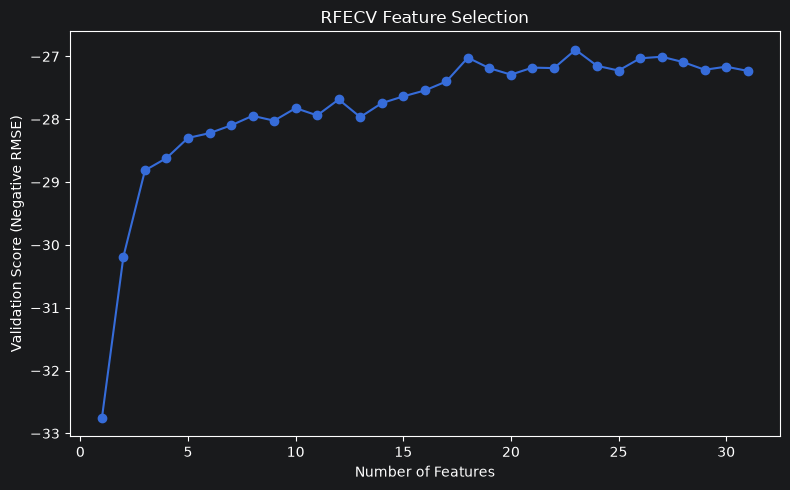

In [37]:
total_features = IMPROVED_BASELINE_2 + CALENDAR_FEATURES

select_features_with_rfecv(total_features, train_df, val_df)

**Observation:** RFECV selected **23 features** as the optimal feature count, with the best validation score occurring at approximately **-26.9 Negative RMSE**. The validation curve shows strong gains with the first few features, followed by steady improvement up to around 18 features. Performance reaches its overall peak at 23 features and then largely plateaus, indicating diminishing returns from additional features.

Among the selected calendar features, `month` was retained while `day_of_week` and `is_weekend` were excluded. Since the calendar feature experiment showed an overall improvement and the selection of `month` suggests that seasonal information may be contributing meaningfully to the model, the RFECV result will be evaluated further rather than discarded.

The reduced feature set suggested by RFECV will therefore be tested against the current calendar-enhanced model to determine whether removing the excluded features improves or maintains validation performance.

In [38]:
REDUCED_IMRPOVED_BASELINE_2 = [
    feature
    for feature in IMPROVED_BASELINE_2
    if feature not in {
        "pm10_lag_1",
        "pm10_lag_2",
        "pm10_lag_3",
        "pm10_roll_mean_3",
        "o3_lag_3",
        "o3_roll_std_7",
    }
]

REDUCED_CALENDAR_FEATURES = [
    "month"
]

reduced_calendar_model, (reduced_calendar_rmse, reduced_calendar_mae, reduced_calendar_r2) = train_and_evaluate_model(train_df, val_df,
                         additonal_features=REDUCED_CALENDAR_FEATURES,
                         label="Reduced Calendar Temporal",
                         compare_model=("Primary Pollutant Temporal",
                                        (primary_pollutant_temporal_rmse, primary_pollutant_temporal_mae, primary_pollutant_temporal_r2)),
                         disable_plot=True,
                         baseline=REDUCED_IMRPOVED_BASELINE_2
                         )

,Target,Primary Pollutant Temporal RMSE,Primary Pollutant Temporal MAE,Primary Pollutant Temporal R²,Reduced Calendar Temporal RMSE,Reduced Calendar Temporal MAE,Reduced Calendar Temporal R²
0,target_aqi_day1,16.004920,10.653828,0.838079,15.959710,10.649035,0.838993
1,target_aqi_day2,28.707930,20.540614,0.487348,28.467838,19.781050,0.495887
2,target_aqi_day3,32.101100,23.710184,0.393819,31.619495,22.923967,0.411871
3,target_aqi_day4,32.298620,24.126421,0.411267,31.793393,23.507599,0.429541
4,Mean,27.278142,19.757762,0.532628,26.960109,19.215413,0.544073


**Observation:** The RFECV-reduced calendar feature set improved overall validation performance compared with the current primary pollutant temporal feature set. Mean RMSE decreased from **27.2781** to **26.9601**, mean MAE decreased from **19.7578** to **19.2154**, and mean R² increased from **0.5326** to **0.5441**.

Performance improved across all four prediction horizons, with the largest gains occurring for day 3 and day 4. Therefore, the RFECV-selected feature set will be retained as the final feature set from this EDA and used in the next notebook, **`02_feature_analysis.ipynb`**, for the subsequent modeling experiments.